In [1]:
%reset -f

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
# os.chdir(config.paths.roots.project)
# os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

In [4]:
from config import config

In [5]:
import torch
torch.cuda.empty_cache()

In [6]:
from utils import logger, MyLogger

Error in callback <bound method AutoreloadMagics.post_execute_hook of <IPython.extensions.autoreload.AutoreloadMagics object at 0x7ca631556810>> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
MyLogger.init_loggers()

# Check Data Module

In [7]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | setup | Train Dataset       : 258 samples
INFO     | setup | Validation Dataset  : 65 samples


In [8]:
dl = dm.train_dataloader()

In [9]:
batch = next(iter(dl))

In [10]:
reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

torch.Size([80, 3, 32, 32]) torch.Size([80, 3, 32, 32])
torch.Size([80, 2]) torch.Size([80, 2])


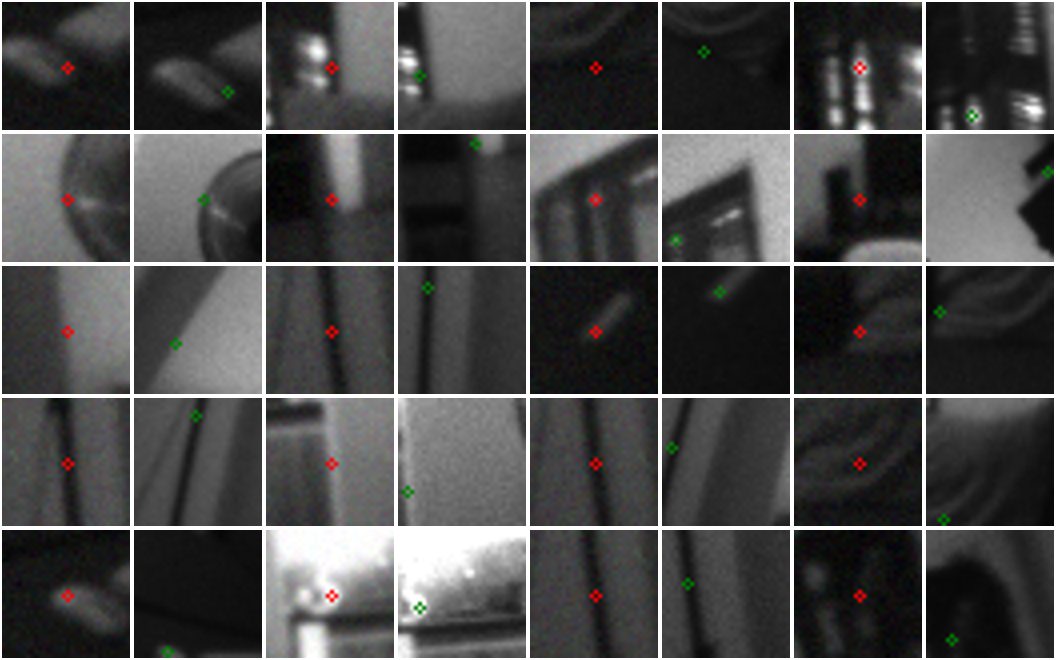

In [11]:
from utils import show_batch

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    limit_count=20, 
    n_columns=4,
)

In [12]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 
# 
#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)


In [13]:
dm.teardown()

# Check Model

In [14]:
from src import MatcherModel
model = MatcherModel()

INFO     | __init__ | Number of Trainable Parameters : 1191504


In [15]:
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

out = model(reference_patches, target_patches, patch_level_reference_coords)

print(f'Output shape : {out.shape}')

reference_patches shape : torch.Size([80, 3, 32, 32])
target_patches shape : torch.Size([80, 3, 32, 32])
patch_level_reference_coords shape : torch.Size([80, 2])
Output shape : torch.Size([80, 2])


# Check Light

In [16]:
from src import Light
light = Light()

INFO     | __init__ | Number of Trainable Parameters : 1191504


In [17]:
target_patch_level_coords_pred = light.forward(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(target_patch_level_coords_pred.shape)

torch.Size([80, 2])
